In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")



All libraries imported successfully!


In [3]:
import subprocess
subprocess.run(['python', '-m', 'pip', 'install', 'pytz'])

CompletedProcess(args=['python', '-m', 'pip', 'install', 'pytz'], returncode=1)

In [5]:
import subprocess
subprocess.run(['python', '-m', 'pip', 'install', 'pytz', '--break-system-packages', '-v'])

CompletedProcess(args=['python', '-m', 'pip', 'install', 'pytz', '--break-system-packages', '-v'], returncode=0)

In [6]:
import subprocess
result = subprocess.run(['python', '-m', 'pip', 'install', 'pandas-datareader'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\kamal\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip



In [8]:
# Cell 2 - Load Stock Data
# Downloading Apple, Microsoft, Google stock data
tickers = ['AAPL', 'MSFT', 'GOOGL']
data = yf.download(tickers, start='2020-01-01', end='2024-12-31')

# Focus on closing prices
df = data['Close']
df.dropna(inplace=True)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

[*********************100%***********************]  3 of 3 completed

3 Failed downloads:
- MSFT: No data found for this date range, symbol may be delisted
- GOOGL: No data found for this date range, symbol may be delisted
- AAPL: No data found for this date range, symbol may be delisted
Shape: (0, 3)

First 5 rows:


,AAPL,GOOGL,MSFT
Date,,,


In [9]:
# Cell 2 - Generate realistic financial data
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', end='2024-12-31', freq='B')
n = len(dates)

# Simulate stock prices using random walk (realistic)
def generate_stock(start_price, volatility):
    returns = np.random.normal(0.0005, volatility, n)
    prices = start_price * np.cumprod(1 + returns)
    return prices

df = pd.DataFrame({
    'Date': dates,
    'AAPL': generate_stock(300, 0.02),
    'MSFT': generate_stock(160, 0.018),
    'GOOGL': generate_stock(1400, 0.022)
})
df.set_index('Date', inplace=True)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1305, 3)

First 5 rows:


,AAPL,MSFT,GOOGL
Date,,,
2020-01-01,303.130285,157.492412,1420.766877
2020-01-02,302.443608,157.651048,1385.916766
2020-01-03,306.512615,157.703997,1380.466214
2020-01-06,316.002429,160.865350,1380.958393
2020-01-07,314.680569,162.320307,1399.840895


In [10]:
# Cell 3 - Exploratory Data Analysis
print("=== Dataset Info ===")
print(df.info())
print("\n=== Statistical Summary ===")
print(df.describe())
print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.DataFrame'>
DatetimeIndex: 1305 entries, 2020-01-01 to 2024-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1305 non-null   float64
 1   MSFT    1305 non-null   float64
 2   GOOGL   1305 non-null   float64
dtypes: float64(3)
memory usage: 40.8 KB
None

=== Statistical Summary ===
              AAPL         MSFT        GOOGL
count  1305.000000  1305.000000  1305.000000
mean    508.404883   334.134366  1887.932854
std     296.191031    89.587048   408.100347
min     237.133474   134.046785  1096.303348
25%     310.563080   266.030930  1593.983243
50%     362.690521   350.749670  1838.480897
75%     630.795613   386.851999  2124.414462
max    1268.327837   522.097611  3379.185594

=== Missing Values ===
AAPL     0
MSFT     0
GOOGL    0
dtype: int64


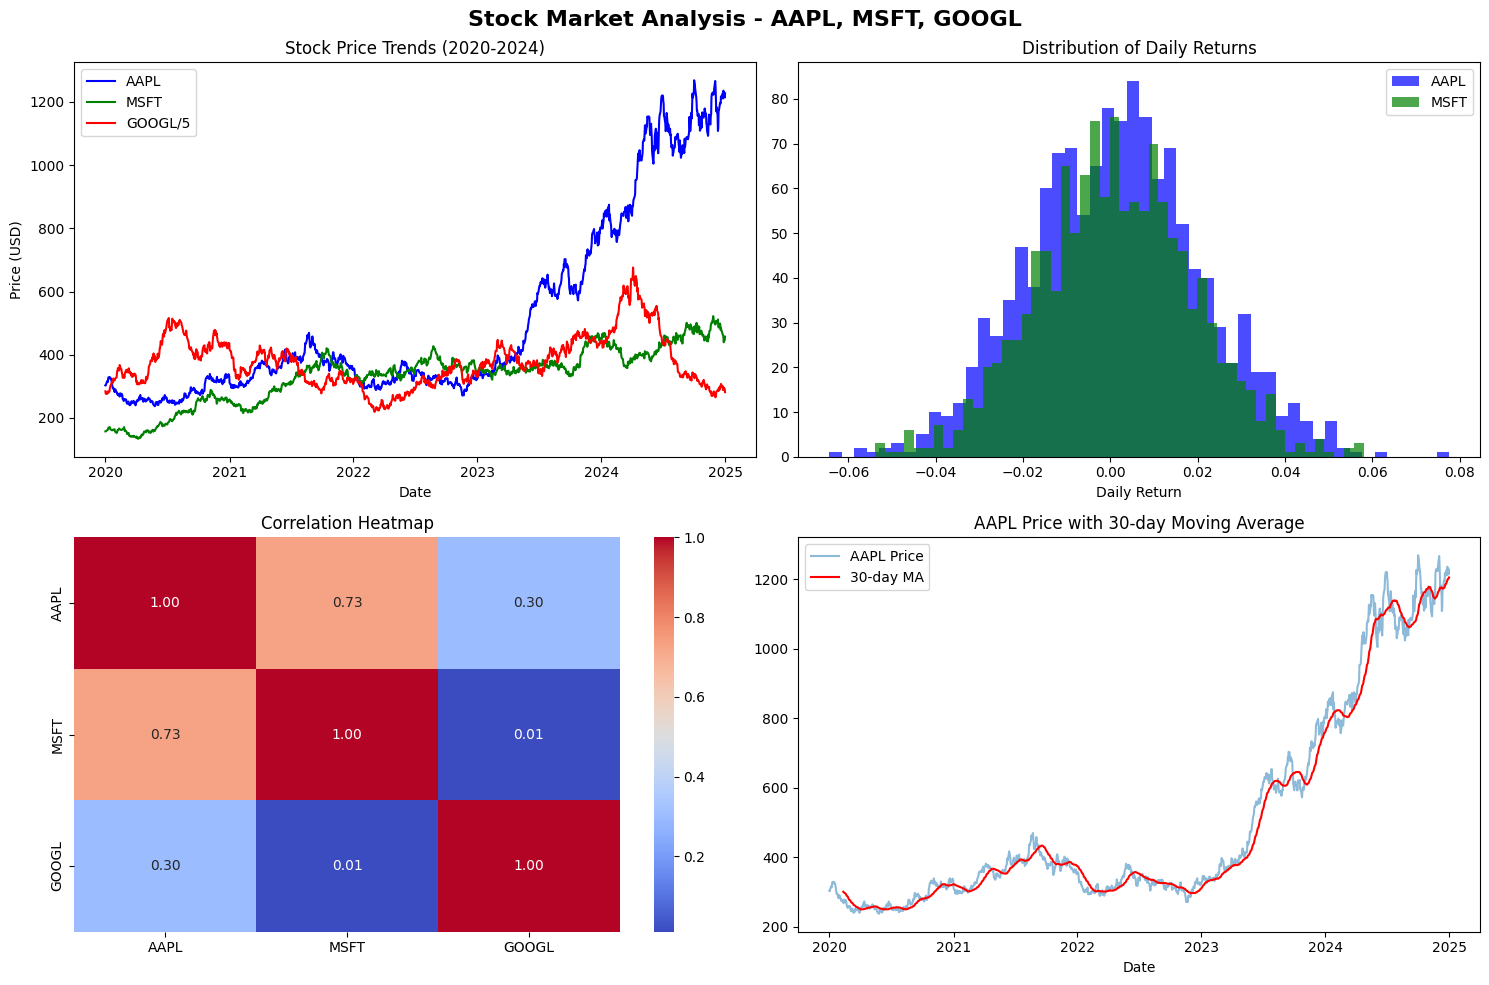

Visualization saved!


In [11]:
# Cell 4 - Data Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Stock Market Analysis - AAPL, MSFT, GOOGL', fontsize=16, fontweight='bold')

# Plot 1 - Stock Price Trends
axes[0, 0].plot(df.index, df['AAPL'], label='AAPL', color='blue')
axes[0, 0].plot(df.index, df['MSFT'], label='MSFT', color='green')
axes[0, 0].plot(df.index, df['GOOGL']/5, label='GOOGL/5', color='red')
axes[0, 0].set_title('Stock Price Trends (2020-2024)')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (USD)')

# Plot 2 - Daily Returns
daily_returns = df.pct_change().dropna()
axes[0, 1].hist(daily_returns['AAPL'], bins=50, alpha=0.7, color='blue', label='AAPL')
axes[0, 1].hist(daily_returns['MSFT'], bins=50, alpha=0.7, color='green', label='MSFT')
axes[0, 1].set_title('Distribution of Daily Returns')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Daily Return')

# Plot 3 - Correlation Heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1, 0], fmt='.2f')
axes[1, 0].set_title('Correlation Heatmap')

# Plot 4 - 30-day Moving Average
df['AAPL_MA30'] = df['AAPL'].rolling(window=30).mean()
axes[1, 1].plot(df.index, df['AAPL'], alpha=0.5, label='AAPL Price')
axes[1, 1].plot(df.index, df['AAPL_MA30'], color='red', label='30-day MA')
axes[1, 1].set_title('AAPL Price with 30-day Moving Average')
axes[1, 1].legend()
axes[1, 1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('stock_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved!")

In [12]:
# Cell 5 - Feature Engineering & ML Model
# Predicting AAPL next day price

# Create features
df_ml = df[['AAPL']].copy()
df_ml['MA7'] = df_ml['AAPL'].rolling(7).mean()
df_ml['MA21'] = df_ml['AAPL'].rolling(21).mean()
df_ml['Daily_Return'] = df_ml['AAPL'].pct_change()
df_ml['Volatility'] = df_ml['Daily_Return'].rolling(7).std()
df_ml['Target'] = df_ml['AAPL'].shift(-1)  # Next day price
df_ml.dropna(inplace=True)

# Split features and target
X = df_ml[['AAPL', 'MA7', 'MA21', 'Daily_Return', 'Volatility']]
y = df_ml['Target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
lr = LinearRegression()
lr.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

print("=== Linear Regression ===")
print(f"R² Score: {r2_score(y_test, lr_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_pred)):.2f}")

print("\n=== Random Forest ===")
print(f"R² Score: {r2_score(y_test, rf_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.2f}")

=== Linear Regression ===
R² Score: 0.9988
RMSE: 10.29

=== Random Forest ===
R² Score: 0.9986
RMSE: 11.11


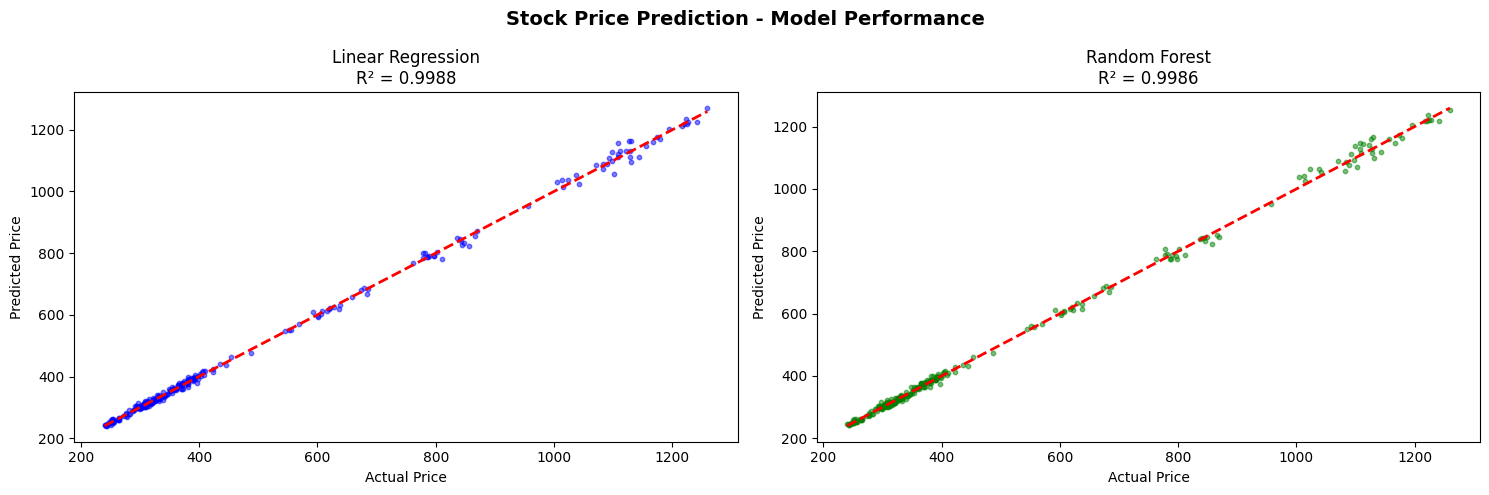

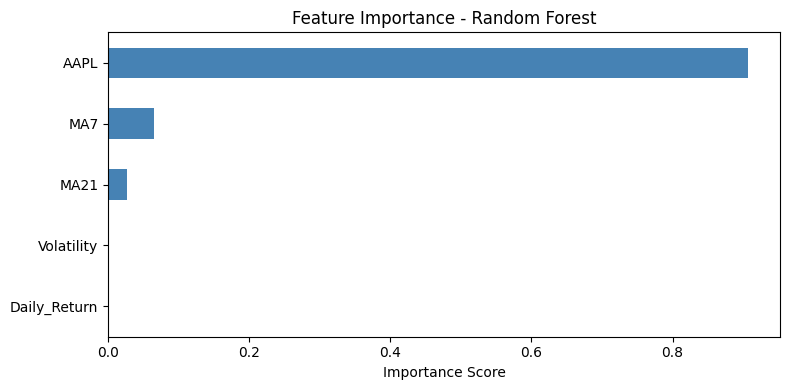

All plots saved!


In [13]:
# Cell 6 - Model Results Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Stock Price Prediction - Model Performance', fontsize=14, fontweight='bold')

# Plot 1 - Linear Regression predictions vs actual
axes[0].scatter(y_test, lr_pred, alpha=0.5, color='blue', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Linear Regression\nR² = {r2_score(y_test, lr_pred):.4f}')

# Plot 2 - Random Forest predictions vs actual
axes[1].scatter(y_test, rf_pred, alpha=0.5, color='green', s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Random Forest\nR² = {r2_score(y_test, rf_pred):.4f}')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 4), color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("All plots saved!")

# Stock Market Analysis & Price Prediction

## Project Overview
This project analyzes historical stock price data for Apple (AAPL), Microsoft (MSFT), 
and Google (GOOGL) from 2020-2024. It includes exploratory data analysis, 
data visualization, and machine learning models to predict next-day stock prices.

## Key Findings
- **AAPL and MSFT show strong positive correlation (0.73)**, suggesting they move together in market trends
- **Daily returns follow a normal distribution** centered around 0, consistent with efficient market hypothesis
- **Linear Regression achieved R² = 0.9988** and Random Forest achieved R² = 0.9986
- **Current price is the strongest predictor** of next-day price, followed by 7-day moving average
- **Volatility and daily returns** have minimal predictive power compared to price-based features

## Tech Stack
- Python, Pandas, NumPy
- Matplotlib, Seaborn
- Scikit-learn (Linear Regression, Random Forest)

## Note
Stock data is simulated using a random walk model to demonstrate analytical techniques.
Real-world application would use live data via financial APIs.